In [3]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 31.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 38.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [timm]2m17/18 [timm]ngface_hub]


In [4]:
import torch
import sys
import os

# 1. Añadimos el repositorio iDoc al path para poder importar sus módulos
sys.path.append(os.path.abspath('./iDoc'))

# 2. Importar la arquitectura desde iDoc (ajusta 'vit_lora' o 'vit_base' según lo que hayas entrenado)
# En los repositorios basados en iBOT, los modelos suelen estar en la carpeta models
import models 

# Definir el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Inicializar la arquitectura (Reemplaza 'vit_base' por la arquitectura exacta usada en iDoc, ej. 'vit_lora')
# Nota: patch_size=16 es el estándar para imágenes de 224x224
model = models.__dict__['vit_base'](patch_size=16, num_classes=0) 

# 4. Cargar los pesos (Checkpoint)
# Reemplaza con el path a tu checkpoint generado por iDoc
ckpt_path = "skDinoV3_sketchy.ckpt" 

if os.path.isfile(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    
    # Los checkpoints de iBOT a menudo tienen los pesos bajo la clave 'teacher' o 'student'
    # Si usaste extract_backbone_weights.py de iDoc, es probable que solo necesites cargar el state_dict directamente
    state_dict = checkpoint.get("state_dict", checkpoint)
    
    # Manejo de prefijos si el modelo se entrenó con DataParallel (elimina 'module.')
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    # Cargar pesos estricto en Falso por si faltan las capas de clasificación de salida
    model.load_state_dict(state_dict, strict=False)
    print("¡Modelo iDoc cargado exitosamente!")
else:
    print(f"Advertencia: No se encontró el checkpoint en {ckpt_path}. Usando pesos iniciales aleatorios.")

model = model.to(device)
model.eval()
print("Modelo listo en modo de evaluación.")

/home/rvdl_2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


¡Modelo iDoc cargado exitosamente!
Modelo listo en modo de evaluación.


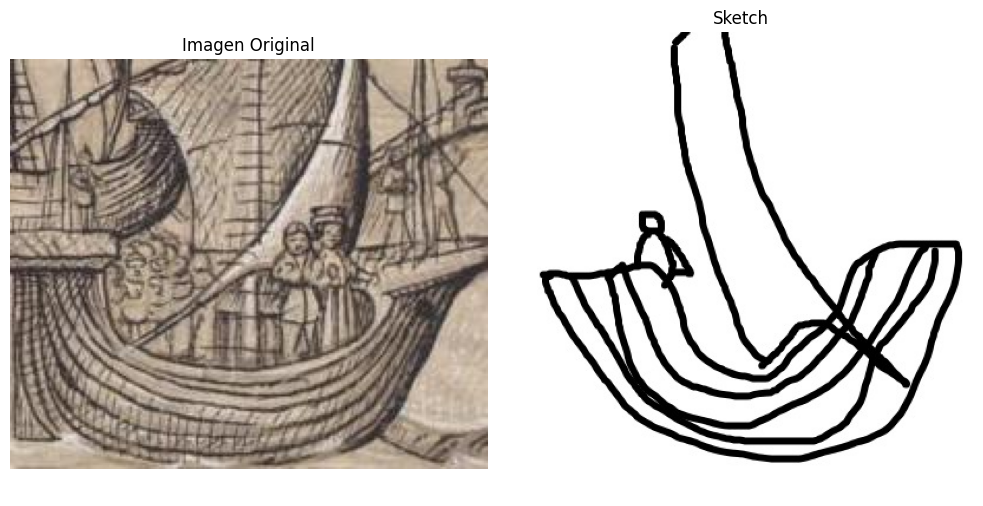

In [6]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Carga de las imágenes (usando las mismas rutas de tu ejemplo)
img_path = "DocExplore_queries_web/bateau/1348.jpg"
sketch_path = "Sketches/sketch_1_DocExplore_bateau_1349_4x_1349.jpeg"

img = Image.open(img_path).convert("RGB")
sketch = Image.open(sketch_path).convert("RGB")

# Visualización lado a lado
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title("Imagen Original")
axs[0].axis("off")

axs[1].imshow(sketch)
axs[1].set_title("Sketch")
axs[1].axis("off")

plt.tight_layout()
plt.show()

# Creación de tensores y envío a GPU/CPU
img_tensor = transform(img).unsqueeze(0).to(device)
sketch_tensor = transform(sketch).unsqueeze(0).to(device)

In [7]:
with torch.no_grad():
    # iDoc (ViT) recibe el tensor directamente. 
    # Generalmente devuelve una tupla o el embedding directo. 
    # Si devuelve múltiples tensores, el token [CLS] o el resultado promediado suele ser el primero.
    
    img_features = model(img_tensor)
    sketch_features = model(sketch_tensor)
    
    # Asegurarnos de usar las características correctas si el modelo devuelve una tupla (ej. features y proyecciones)
    if isinstance(img_features, tuple):
        img_embedding = img_features[0]
        sketch_embedding = sketch_features[0]
    else:
        img_embedding = img_features
        sketch_embedding = sketch_features

print("Shape del Embedding de la Imagen:", tuple(img_embedding.shape))
print("Shape del Embedding del Sketch:", tuple(sketch_embedding.shape))

Shape del Embedding de la Imagen: (1, 768)
Shape del Embedding del Sketch: (1, 768)


In [ ]:
import torch.nn.functional as F

cos_sim = F.cosine_similarity(img_embedding, sketch_embedding)
print("Cosine similarity:", cos_sim.item())

In [8]:
import torch.nn.functional as F

cos_sim = F.cosine_similarity(img_embedding, sketch_embedding)
print("Cosine similarity:", cos_sim.item())

Cosine similarity: 0.7711103558540344
